In [1]:
import torch, cv2, celldetection as cd, numpy as np
from matplotlib import pyplot as plt
import pandas as pd

IMG_FILE_NAME = "Image3.png"

# Load pretrained model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = cd.fetch_model("ginoro_CpnResNeXt101UNet-fbe875f1a3e5ce2c", check_hash=True).to(device)
model.eval()


c:\Users\Jack\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Jack\AppData\Roaming\Python\Python310\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
C:\Users\Jack\AppData\Roaming\Python\Python310\site-packages\celldetection\models\mamba.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @autocast(enabled=False)


CpnResNeXt101UNet(
  (core): CPNCore(
    (backbone): ResNeXt101UNet(
      (normalize): Normalize(
        (assert_range): (0.0, 1.0)
        (norm): Compose(
            Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        )
      )
      (body): IntermediateLayerGetter(
        (0): Sequential(
          (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Sequential(
          (0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

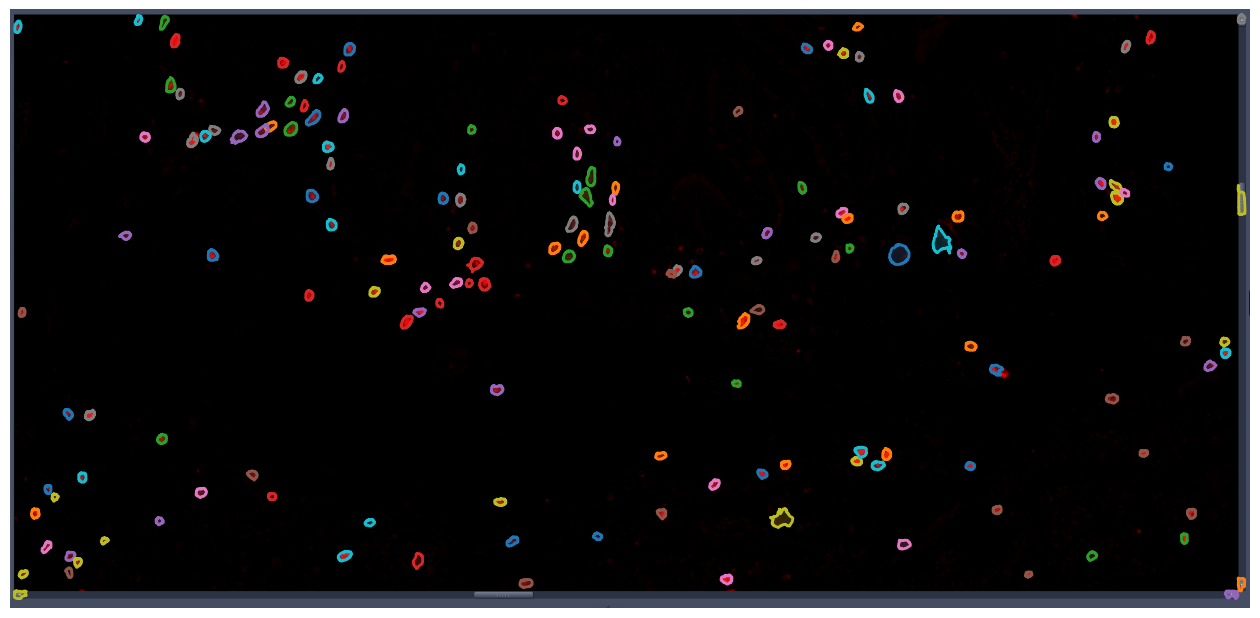

In [2]:
img = cv2.imread(IMG_FILE_NAME, cv2.IMREAD_COLOR_RGB)

# Running model
with torch.no_grad():
    x = cd.to_tensor(img, transpose=True, device=device, dtype=torch.float32)
    x = x / 255  # ensure 0 -> 1 range
    x = x[None]  # add batch dimension: Tensor[3, h, w] -> Tensor[1, 3, h, w]
    y = model(x)
    contours = y["contours"][0]  # [0] as contours is length of number of images 
contours_np = contours.numpy() # converts tensor to np to be easier to work with

_ = plt.subplots(1,1, figsize = (16,16))
plt.imshow(img)
cd.plot_contours(contours)
plt.axis('off')
plt.show()

In [3]:
def filled_mask_from_contour(contour, img):
    bounding = cv2.boundingRect(contour)
    mask = np.zeros_like(img)

    x_to_search, y_to_search= range(bounding[0],bounding[0]+bounding[2]),range(bounding[1],bounding[1]+bounding[3])

    for x in x_to_search:
        for y in y_to_search:
            if cv2.pointPolygonTest(contour,[x,y],measureDist=False) in (0,1): # if inside the contour
                mask[y][x] = 1
    return mask

def describe_contours(contours:np.ndarray):
    contour_data = np.zeros((len(contours),3))
    for c in range(len(contours)):
        M = cv2.moments(contours[c])
        contour_data[c] = [M["m10"]/M["m00"], M["m01"]/M["m00"], cv2.contourArea(contours[c])]
        # structure is [centroid_x, centroid_y, area]
    return pd.DataFrame(data = contour_data, columns=["centre_x","centre_y","area"]).round(3)




def result_statistics(contours:np.ndarray, img_grey):
    filled_mask = np.zeros_like(img_grey)

    for contour_i in contours:
        filled_mask = np.logical_or(filled_mask,filled_mask_from_contour(np.array(contour_i).round(),img_grey))
    
    contour_df = describe_contours(contours_np)
    
    return pd.Series(pd.DataFrame(
        {
            "Count":len(contour_df),
            "Mean Area":contour_df["area"].mean(),
            "S.D. of Area":contour_df["area"].std(),
            "Approximate Total Area":filled_mask.sum(),
            "Proportion of Image Occupied":filled_mask.sum()/(img_grey.shape[0]*img_grey.shape[1])
        },
        index = ["Results"]
    ).loc["Results"].transpose())


img_grey = cv2.imread(IMG_FILE_NAME,cv2.IMREAD_GRAYSCALE)
result_statistics(contours_np,img_grey)


Count                             160.000000
Mean Area                         144.436156
S.D. of Area                       76.338814
Approximate Total Area          27447.000000
Proportion of Image Occupied        0.016882
Name: Results, dtype: float64